# 03 — Experiment 1: does the nudge cost us orders? (z-test)

## Hypotheses — stated before a single number is computed

| | |
| --- | --- |
| Unit | one cart session = one user |
| Metric | `order_placed`, binary |
| **H₀** | p_treatment = p_control — the nudge does not change the order rate |
| **H₁** | p_treatment ≠ p_control — **two-sided** |
| α | 0.05 |
| Power | 0.80 |
| Test | pooled two-proportion **z-test** |

**Why two-sided.** A nudge that makes the ₹35 delivery fee more salient could plausibly
push conversion either way: it might sell the free-delivery benefit, or it might remind
a price-sensitive shopper that delivery is not free today. Choosing one-sided after
seeing the direction is how a 5% false-positive rate quietly becomes 10%.

**Why a z-test and not a t-test.** The outcome is Bernoulli, so `Var = p(1-p)` — the
variance is a *function* of the parameter being estimated, not a second unknown. The
t distribution exists to pay for the uncertainty in an independently estimated σ̂; here
there is none to pay for. With n ≈ 80,000 per arm the CLT makes the difference in
proportions normal, and z is the correct reference distribution.

In [1]:
import math
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

ALPHA = 0.05
POWER = 0.80
Z_ALPHA_TWO_SIDED = stats.norm.ppf(1 - ALPHA / 2)   # 1.96
Z_POWER_80 = stats.norm.ppf(POWER)                  # 0.8416

df = (
    pd.read_csv(Path("../data/qb_cart_sessions.csv"), parse_dates=["session_ts"])
    .drop_duplicates(subset="session_id")           # the double-fired analytics rows
)
df["device"] = df["device"].str.lower()
df["week"] = ((df["session_ts"] - df["session_ts"].min()).dt.days // 7 + 1).clip(1, 4)
print(f"{len(df):,} de-duplicated sessions")

160,000 de-duplicated sessions


## 0. The test, written out

`scipy.stats` covers t-tests, chi-square and the rest, but there is no two-proportion
z-test outside `statsmodels`. It is a dozen lines of arithmetic and writing it out is the
point of this notebook — every term is visible rather than buried behind a function name.

Note the **two different standard errors**:

* the **pooled** SE for the test statistic — under H₀ both arms share one true p, so the
  best estimate of it uses all the data;
* the **unpooled** SE for the confidence interval — once you are estimating a difference
  rather than testing a null, there is no reason to assume the arms share anything.

Using the pooled SE for the interval is a common and subtly wrong shortcut.

In [2]:
@dataclass(frozen=True)
class ZTestResult:
    control_n: int
    treatment_n: int
    control_rate: float
    treatment_rate: float
    absolute_lift: float
    lift_ci: tuple[float, float]
    z_statistic: float
    p_value: float
    mde: float


def two_proportion_z_test(frame, outcome="order_placed"):
    """Two-sided, pooled two-proportion z-test on a binary outcome column."""
    arms = frame.groupby("group")[outcome].agg(["size", "sum"])
    control_n, treatment_n = arms.loc["control", "size"], arms.loc["treatment", "size"]
    control_rate = arms.loc["control", "sum"] / control_n
    treatment_rate = arms.loc["treatment", "sum"] / treatment_n
    lift = treatment_rate - control_rate

    pooled = arms["sum"].sum() / arms["size"].sum()
    pooled_se = math.sqrt(pooled * (1 - pooled) * (1 / control_n + 1 / treatment_n))
    z = lift / pooled_se

    unpooled_se = math.sqrt(
        control_rate * (1 - control_rate) / control_n
        + treatment_rate * (1 - treatment_rate) / treatment_n
    )
    margin = Z_ALPHA_TWO_SIDED * unpooled_se

    return ZTestResult(
        control_n=int(control_n), treatment_n=int(treatment_n),
        control_rate=control_rate, treatment_rate=treatment_rate,
        absolute_lift=lift, lift_ci=(lift - margin, lift + margin),
        z_statistic=z, p_value=2 * stats.norm.sf(abs(z)),
        mde=minimum_detectable_effect(control_rate, control_n, treatment_n),
    )


def minimum_detectable_effect(baseline, control_n, treatment_n):
    """Smallest absolute lift detectable at alpha = 0.05 with 80% power.

    Solved by bisection because the alternative-hypothesis SE depends on the effect itself.
    """

    def threshold(effect):
        null_se = math.sqrt(baseline * (1 - baseline) * (1 / control_n + 1 / treatment_n))
        alternative_se = math.sqrt(
            baseline * (1 - baseline) / control_n
            + (baseline + effect) * (1 - baseline - effect) / treatment_n
        )
        return Z_ALPHA_TWO_SIDED * null_se + Z_POWER_80 * alternative_se

    low, high = 0.0, 1 - baseline
    for _ in range(60):
        middle = (low + high) / 2
        if middle >= threshold(middle):
            high = middle
        else:
            low = middle
    return high

## 1. Gate: sample ratio mismatch

Read the split before reading the result. If the allocation is broken, every number
after it is describing a self-selected population, not a randomised one.

In [3]:
# chisquare with no expected frequencies assumes a uniform split -- exactly the 50/50 null.
counts = df["group"].value_counts()
chi2, srm_p = stats.chisquare([counts["control"], counts["treatment"]])
print(f"control {counts['control']:,}  treatment {counts['treatment']:,}")
print(f"chi2 = {chi2:.2f}, p = {srm_p:.3f}  ->  {'PASS' if srm_p > 0.001 else 'FAIL'}")

control 79,960  treatment 80,040
chi2 = 0.04, p = 0.841  ->  PASS


The overall split passes. Notebook 01 found the SRM lives inside web traffic only;
section 6 re-runs the headline without web to confirm it does not drive the result.

## 2. The test

In [4]:
result = two_proportion_z_test(df)

print(f"control    {result.control_rate:.4f}   (n = {result.control_n:,})")
print(f"treatment  {result.treatment_rate:.4f}   (n = {result.treatment_n:,})")
print(f"\nabsolute lift   {result.absolute_lift * 100:+.2f} pp")
print(f"relative lift   {result.absolute_lift / result.control_rate * 100:+.2f} %")
print(f"95% CI          [{result.lift_ci[0] * 100:+.2f}, {result.lift_ci[1] * 100:+.2f}] pp")
print(f"z statistic     {result.z_statistic:.2f}")
print(f"p-value         {result.p_value:.2e}")

control    0.3438   (n = 79,960)
treatment  0.3203   (n = 80,040)

absolute lift   -2.35 pp
relative lift   -6.83 %
95% CI          [-2.81, -1.89] pp
z statistic     -9.98
p-value         1.91e-23


### Reading the output

**z = −9.98.** The observed gap is ten standard errors below zero. Under H₀ that is
effectively impossible — p ≈ 2e-23.

**Reject H₀.** The nudge reduces conversion by **2.35 percentage points**, from 34.4% to
32.0% — a 6.8% relative drop in orders.

**The two standard errors from section 0 are visible in the numbers below.** They are
nearly identical here because the arms have similar rates and similar sizes — but that is
a property of this experiment, not a rule.

In [5]:
se_pooled = result.absolute_lift / result.z_statistic
print(f"pooled SE (used for z)      {se_pooled:.6f}")
print(f"unpooled SE (used for CI)   {(result.lift_ci[1] - result.lift_ci[0]) / (2 * 1.96):.6f}")

pooled SE (used for z)      0.002355
unpooled SE (used for CI)   0.002354


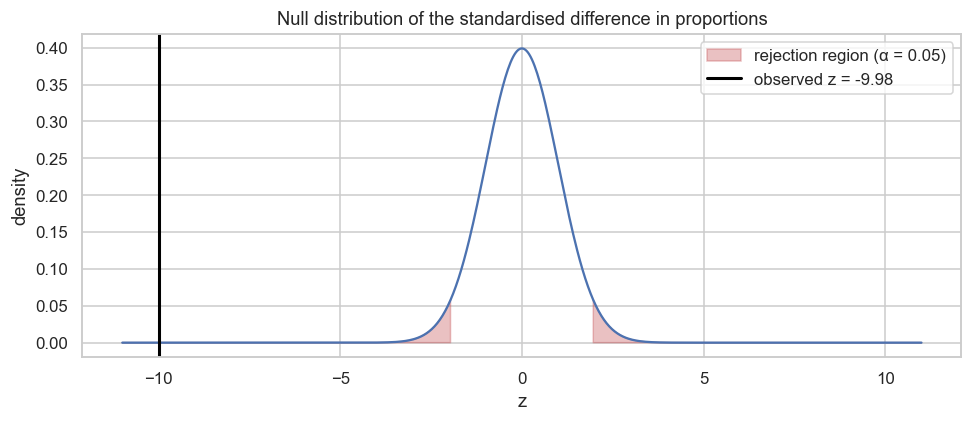

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
grid = np.linspace(-11, 11, 600)
ax.plot(grid, np.exp(-grid**2 / 2) / np.sqrt(2 * np.pi), color="#4C72B0")
ax.fill_between(grid, 0, np.exp(-grid**2 / 2) / np.sqrt(2 * np.pi),
                where=np.abs(grid) >= 1.96, color="#C44E52", alpha=0.35,
                label="rejection region (α = 0.05)")
ax.axvline(result.z_statistic, color="black", lw=2, label=f"observed z = {result.z_statistic:.2f}")
ax.set(title="Null distribution of the standardised difference in proportions",
       xlabel="z", ylabel="density")
ax.legend()
plt.tight_layout()

## 3. Was the experiment powered to see this?

A significant result on a huge sample can still be a trivial one, so state up front what
effect the design was built to detect. The minimum detectable effect is the smallest
absolute lift this sample size can find at α = 0.05 with 80% power.

In [7]:
print(f"MDE at 80% power   {result.mde * 100:.2f} pp")
print(f"observed effect    {abs(result.absolute_lift) * 100:.2f} pp")
print(f"ratio              {abs(result.absolute_lift) / result.mde:.1f}x the MDE")

MDE at 80% power   0.67 pp
observed effect    2.35 pp
ratio              3.5x the MDE


The observed loss is 3.5× the smallest effect the design could resolve, and the entire
95% interval — [−2.81, −1.89] pp — sits well away from zero. This is not a
marginally-powered result being over-read.

The mirror-image question matters too: **had the result been null**, would that null have
meant anything? With an MDE of 0.67 pp, yes — a null would have ruled out any effect
larger than about two-thirds of a point. An underpowered null rules out nothing.

## 4. Segment tests, with a multiple-comparison correction

Notebook 01 showed the gap is not uniform across city tiers. Testing each tier separately
is legitimate here because the split was **pre-registered** — tier-3 baskets sit far below
the ₹499 threshold, so there was a mechanism-based reason to expect a different effect
there before looking at the data.

It still costs something. Three tests at α = 0.05 give roughly a 14% chance of at least
one false positive under a true null. Bonferroni fixes that by dividing: α = 0.05 / 3 =
**0.0167**. It is conservative, and that is the right trade when a false "this segment is
fine" would ship a losing change to a whole market.

In [8]:
def segment_test(frame, key, value):
    outcome = two_proportion_z_test(frame[frame[key] == value])
    return {
        "segment": value,
        "n": outcome.control_n + outcome.treatment_n,
        "control": outcome.control_rate,
        "treatment": outcome.treatment_rate,
        "lift_pp": outcome.absolute_lift * 100,
        "ci_low_pp": outcome.lift_ci[0] * 100,
        "ci_high_pp": outcome.lift_ci[1] * 100,
        "z": outcome.z_statistic,
        "p_value": outcome.p_value,
    }


tiers = ["metro", "tier_2", "tier_3"]
bonferroni = ALPHA / len(tiers)
tier_results = pd.DataFrame([segment_test(df, "city_tier", tier) for tier in tiers])
tier_results["significant"] = tier_results["p_value"] < bonferroni
tier_results.set_index("segment")

,n,control,treatment,lift_pp,ci_low_pp,ci_high_pp,z,p_value,significant
segment,,,,,,,,,
metro,63731,0.3634,0.3521,-1.1252,-1.8695,-0.3810,-2.9631,0.0030,True
tier_2,56211,0.3441,0.3267,-1.7360,-2.5165,-0.9555,-4.3586,0.0000,True
tier_3,40058,0.3124,0.2604,-5.2052,-6.0891,-4.3212,-11.5218,0.0000,True


All three tiers lose conversion, and all three survive the Bonferroni threshold — but the
**magnitude ranges from about 1 pp to over 5 pp**. Tier-3 loses five times what metro
does.

The mechanism is exactly what the pre-registration predicted: a tier-3 shopper whose
basket is typically ~₹360 sees a banner asking for another ₹140 they were not going to
spend. The nudge does not sell them free delivery; it just makes the ₹35 fee salient at
the moment of checkout.

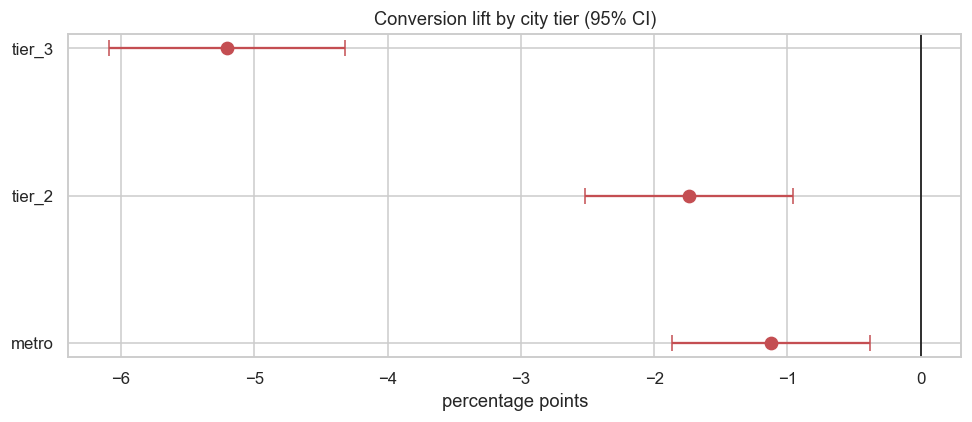

In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.errorbar(tier_results["lift_pp"], tier_results["segment"],
            xerr=[tier_results["lift_pp"] - tier_results["ci_low_pp"],
                  tier_results["ci_high_pp"] - tier_results["lift_pp"]],
            fmt="o", color="#C44E52", capsize=5, ms=8)
ax.axvline(0, color="black", lw=1)
ax.set(title="Conversion lift by city tier (95% CI)", xlabel="percentage points")
plt.tight_layout()

In [10]:
devices = ["android", "ios", "web"]
device_results = pd.DataFrame([segment_test(df, "device", device) for device in devices])
device_results["significant"] = device_results["p_value"] < ALPHA / len(devices)
device_results.set_index("segment")

,n,control,treatment,lift_pp,ci_low_pp,ci_high_pp,z,p_value,significant
segment,,,,,,,,,
android,99217,0.3467,0.3182,-2.8445,-3.4305,-2.2584,-9.5101,0.0000,True
ios,36899,0.3383,0.3239,-1.4483,-2.4085,-0.4880,-2.9557,0.0031,True
web,23884,0.3406,0.3237,-1.6864,-2.8811,-0.4918,-2.7655,0.0057,True


## 5. Novelty check — is the loss stable over time?

A cart change can shock behaviour in week 1 and then be absorbed. If the loss shrinks
week over week, the pooled estimate over-states the long-run cost.

In [11]:
weekly = []
for week in sorted(df["week"].unique()):
    outcome = two_proportion_z_test(df[df["week"] == week])
    weekly.append({"week": week, "lift_pp": outcome.absolute_lift * 100,
                   "z": outcome.z_statistic, "p_value": outcome.p_value})
weekly = pd.DataFrame(weekly).set_index("week")
weekly

,lift_pp,z,p_value
week,,,
1,-1.8186,-3.6045,0.0003
2,-2.5665,-5.2088,0.0000
3,-2.3080,-4.9550,0.0000
4,-2.6072,-6.0463,0.0000


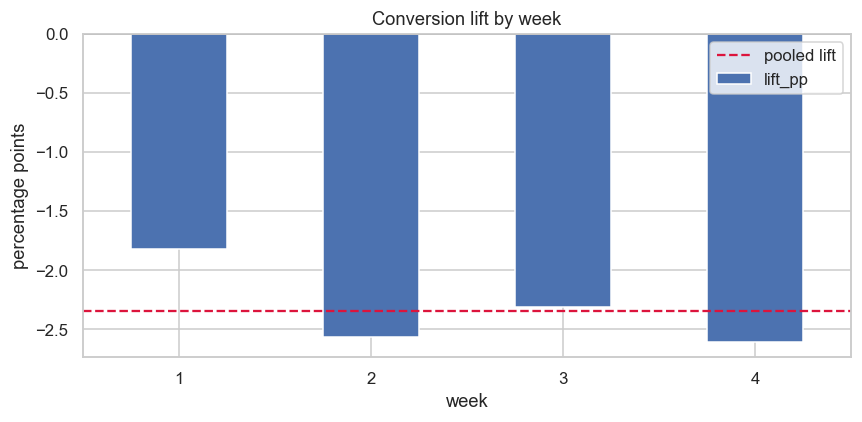

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
weekly["lift_pp"].plot(kind="bar", ax=ax, color="#4C72B0", rot=0)
ax.axhline(result.absolute_lift * 100, color="crimson", ls="--", label="pooled lift")
ax.axhline(0, color="black", lw=1)
ax.set(title="Conversion lift by week", ylabel="percentage points")
ax.legend()
plt.tight_layout()

The loss is present in every week and does not trend towards zero. Unlike the basket
lift (notebook 02), the conversion cost is **not** a novelty effect — it is the steady
state.

## 6. Robustness: drop the segment with the SRM

Web traffic carries a genuine sample-ratio mismatch. It is only 15% of sessions, but the
conclusion should not depend on a segment whose bucketing is known to be broken.

In [13]:
web_free = two_proportion_z_test(df[df["device"] != "web"])
print(f"all traffic       lift {result.absolute_lift * 100:+.2f} pp   z = {result.z_statistic:.2f}")
print(f"excluding web     lift {web_free.absolute_lift * 100:+.2f} pp   z = {web_free.z_statistic:.2f}")

all traffic       lift -2.35 pp   z = -9.98
excluding web     lift -2.47 pp   z = -9.66


Effectively unchanged. The headline does not rest on the broken segment.

## Verdict on experiment 1

> **Reject H₀.** The free-delivery nudge reduces conversion by **2.35 pp**
> (95% CI [−2.81, −1.89], z = −9.98, p ≈ 2e-23) — a 6.8% relative fall in orders.
> The loss is stable across all four weeks and present in all three city tiers, but it is
> roughly five times larger in tier-3 (−5.2 pp) than in metro (−1.1 pp).

On its own this experiment says **kill the nudge**.

That would be the wrong call, and the reason is a metric problem, not a statistics
problem. Orders are not what QuickBasket is trying to maximise — margin is. The nudge is
supposed to trade a few orders for materially bigger baskets. This test measured only one
side of that trade.

Experiment 2 measures the other side, on the same randomised population, with a
continuous metric and a t-test.